In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("amazon_raw.csv")
df.head()
df.tail()
df.columns
df.shape
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [3]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [4]:
missing_percentage=df.isnull().mean()*100
missing_percentage.sort_values(ascending=False)

rating_count           0.136519
product_id             0.000000
product_name           0.000000
category               0.000000
discounted_price       0.000000
actual_price           0.000000
discount_percentage    0.000000
rating                 0.000000
about_product          0.000000
user_id                0.000000
user_name              0.000000
review_id              0.000000
review_title           0.000000
review_content         0.000000
img_link               0.000000
product_link           0.000000
dtype: float64

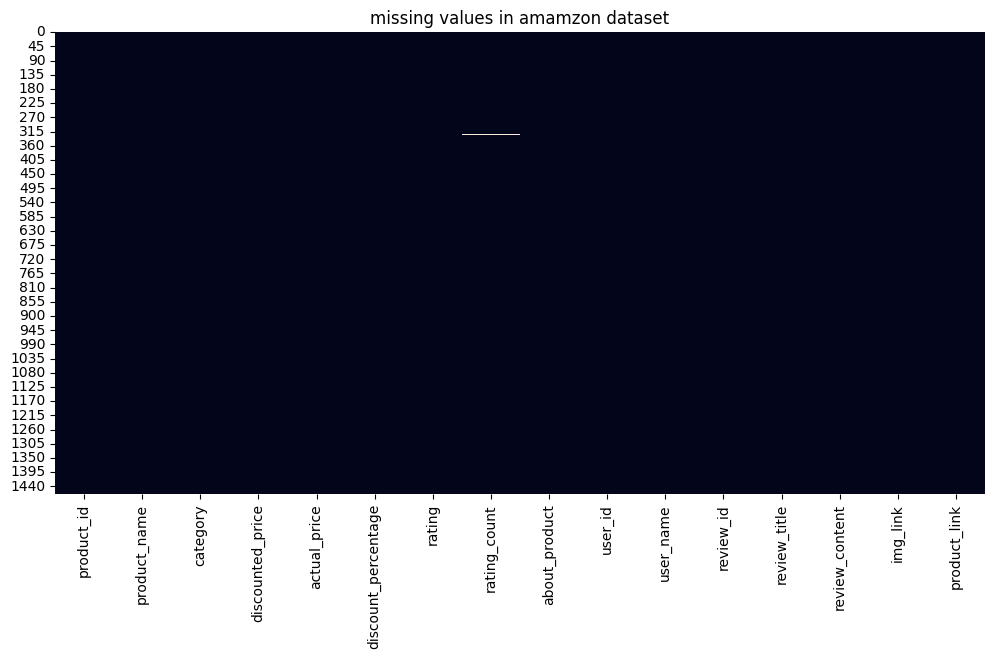

In [5]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False)
plt.title("missing values in amamzon dataset")
plt.show()

In [6]:
df.duplicated().sum()
df=df.drop_duplicates()
df.duplicated().sum()


0

In [7]:
df['discounted_price']=(
    df['discounted_price'].astype(str).str.replace("rs.","").str.replace(",","")
)

df['discounted_price']=pd.to_numeric(
    df['discounted_price'],errors="coerce"
)
df['actual_price']=(
    df['actual_price'].astype(str).str.replace("rs.","").str.replace(",","")
)

df['actual_price']=pd.to_numeric(
    df['actual_price'],errors="coerce"
)


In [8]:
df['discount_percentage']=(
    df['discount_percentage'].astype(str).str.replace("%","",regex=False)
)
df['discount_percentage']=pd.to_numeric(
    df['discount_percentage'],errors="coerce"
)

df['rating'].unique()
df['rating']=pd.to_numeric(df['rating'],errors="coerce")

df['rating'].isnull().sum()
df['rating']=df['rating'].fillna(df['rating'].median())

df['rating_count']=(
    df['rating_count'].astype(str).str.replace(",","",regex=False)
)

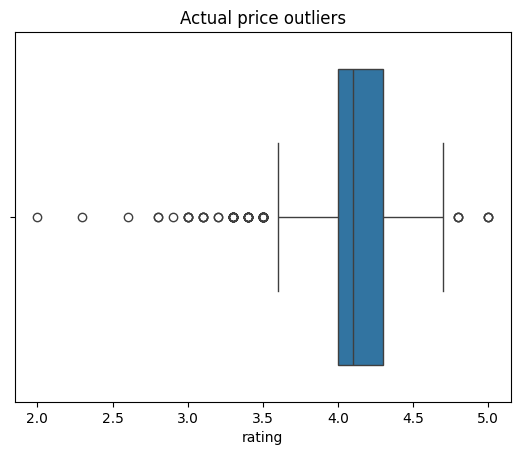

In [9]:
sns.boxplot(x=df['rating']
)
plt.title("Actual price outliers")
plt.show()

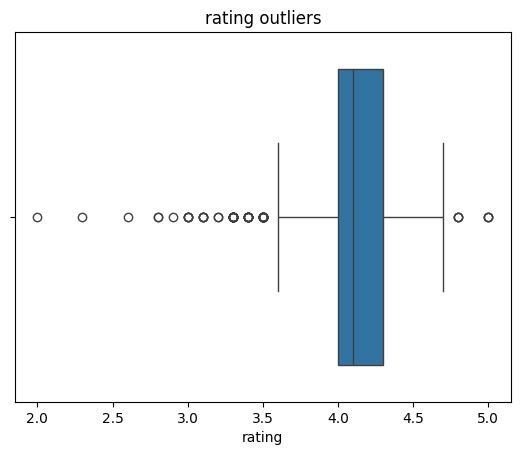

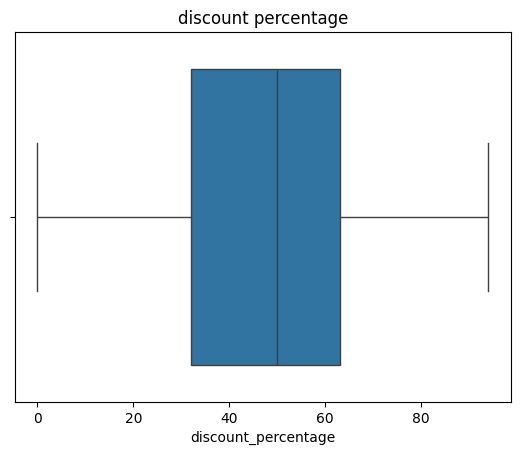

In [10]:
sns.boxplot(x=df['rating'])
plt.title("rating outliers")
plt.show()

sns.boxplot(x=df['discount_percentage'])
plt.title("discount percentage")
plt.show()

In [11]:
Q1 = df["actual_price"].quantile(0.25)
Q3 = df["actual_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [12]:
df = df[
    (df["actual_price"] >= lower) &
    (df["actual_price"] <= upper)
]

In [13]:
df["discount_amount"] = (
    df["actual_price"] -
    df["discounted_price"]
)
df["discount_ratio"] = (
    df["discount_amount"] /
    df["actual_price"]
)


In [14]:
df["price_category"] = np.select(
    [
        df["discounted_price"] < 500,
        df["discounted_price"].between(500, 2000),
        df["discounted_price"] > 2000
    ],
    [
        "Low Price",
        "Medium Price",
        "High Price"
    ],
    default="Unknown"
)
df["price_category"].value_counts()

Series([], Name: count, dtype: int64)

In [27]:
df["rating_category"] = np.select(
    [
        df["rating"] >= 4.5,
        df["rating"] >= 4.0,
        df["rating"] >= 3.0
    ],
    [
        "Excellent",
        "Good",
        "Average"
    ],
    default="Poor"
)


In [25]:
category_count = (
    df["category"]
    .value_counts()
)

